In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.optimize import curve_fit

/home/ivan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
def sigmodal_response( X, EC50, HS, Bot, Top):
    return ((Top - Bot)/(1 + ((X/EC50)**HS))) + Bot

In [4]:
os.chdir('/home/ivan/Desktop/Projects/BaF3 BCRABL Asc Imat DR241124')

In [5]:
raw_data = pd.read_csv('BaF3 DR241124 Asc Imat Assay 746.csv')
plate_num = pd.read_csv('BaF3 DR241124 PLATE CELLS.csv')
drug_map = pd.read_csv('BaF3 DR241124 Asc Imat  Map.csv')
data_plate = pd.merge(plate_num, raw_data, on='PlateNumber')
data = pd.merge(data_plate, drug_map, on='Well')

In [6]:
sigmoid_para = []
sigmoid_fits = []
sigmoid_var = []

data['Norm'] = 1.0
for plate in data['PlateNumber'].drop_duplicates():
    DMSO_signal = data.loc[(data['PlateNumber']==plate) & (data['Conc']==0), 'Signal'].mean()
    data.loc[(data['PlateNumber']==plate), 'Norm'] = data.loc[(data['PlateNumber']==plate), 'Signal'] / DMSO_signal
    for drug in data.loc[data['PlateNumber']==plate, 'Drug'].drop_duplicates():
        data_drug = data.loc[(data['PlateNumber']==plate) & (data['Drug']==drug)]
        cell = data_drug['Cell'].drop_duplicates().values[0]
        data_drug = data_drug[['Conc', 'Norm']].groupby('Conc').mean().reset_index()
        popt, pcov = curve_fit(sigmodal_response, data_drug['Conc'], data_drug['Norm'], 
                               p0=(data_drug['Conc'].median(), 1, 0, 1),
                               bounds=((0 ,0,0,0.5),(data_drug['Conc'].max()*2,5,0.5,1.5)))
        conc_space = np.logspace(np.log10(data_drug['Conc'].nsmallest(2).iloc[-1]), np.log10(data_drug['Conc'].max()), 200)
        fit_line = sigmodal_response(conc_space, *popt)
        sigmoid_var.append([cell, drug, *np.sqrt(np.diag(pcov))])
        sigmoid_para.append([cell, drug, *popt])
        for i in range(len(conc_space)):
            sigmoid_fits.append([cell, drug, conc_space[i], fit_line[i]])

In [7]:
parameter_DF = pd.DataFrame(sigmoid_para, columns=['Cell','Drug', 'EC50', 'HS', 'Bot', 'Top']).round(2)
var_DF = pd.DataFrame(sigmoid_var, columns=['Cell','Drug', 'EC50', 'HS', 'Bot', 'Top']).round(2)
fit_DF = pd.DataFrame(sigmoid_fits, columns=['Cell', 'Drug', 'Conc', 'Responce'])
data['Norm'] = data['Norm']*100
fit_DF['Responce'] = fit_DF['Responce']*100

In [9]:
parameter_DF.pivot(index='Cell', columns='Drug', values=["EC50", 'Bot'])

EC50                 Bot         
Drug       asciminib  imatinib asciminib imatinib
Cell                                             
BaF3          619.16   5637.68      0.50     0.50
E505G         119.74    149.28      0.00     0.00
F72P           69.53    168.08      0.28     0.00
G130E          15.23     92.24      0.00     0.00
G76R            6.31    182.30      0.00     0.00
M244V          35.00    461.94      0.04     0.00
T315I          47.35  20000.00      0.10     0.05
V468F         107.65    240.04      0.40     0.00
V73A            6.05    167.36      0.00     0.00
V73A Y253H     41.36   8448.66      0.00     0.00
WT              2.30    177.63      0.00     0.00
Y139C          12.83    133.38      0.00     0.00
Y253H           5.04   8078.19      0.00     0.00
Y342A          42.33    173.98      0.00     0.00

In [10]:
sns.set_context('notebook')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

In [11]:
intrest = ['BaF3', 'WT', 'V73A', 'Y253H', 'V73A Y253H', 'M244V']
Asc_fit = fit_DF.loc[(fit_DF['Cell'].isin(intrest)) & (fit_DF['Drug']=='asciminib')]
Asc_data = data.loc[(data['Cell'].isin(intrest)) & (data['Drug']=='asciminib')]

In [12]:
['#A9A9A9'] + sns.color_palette()

['#A9A9A9',
 (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

/tmp/ipykernel_272799/923464905.py:2: UserWarning: The palette list has more values (11) than needed (6), which may not be intended.
  drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Cell', data=Asc_fit, hue_order = intrest, palette=['#A9A9A9'] + sns.color_palette())
/tmp/ipykernel_272799/923464905.py:4: UserWarning: The palette list has more values (11) than needed (6), which may not be intended.
  drug_resp = sns.lineplot(x='Conc', y='Norm', hue='Cell',  marker='o', linestyle='',
/tmp/ipykernel_272799/923464905.py:6: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel='Asciminib (nM)', xlim = [0,1000], ylim = [-2, 120])


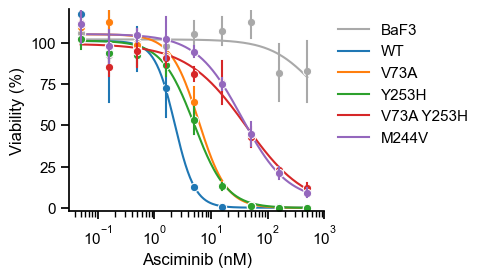

In [13]:
mpl.rcParams['figure.figsize'] = 5,3
drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Cell', data=Asc_fit, hue_order = intrest, palette=['#A9A9A9'] + sns.color_palette())
#sns.scatterplot(x='Conc', y='Norm', hue='Cell', hue_order = intrest, data=Asc_data , palette=['#A9A9A9'] + sns.color_palette(), legend=False)
drug_resp = sns.lineplot(x='Conc', y='Norm', hue='Cell',  marker='o', linestyle='',
                         errorbar = 'sd', err_style='bars', hue_order = intrest, data=Asc_data , palette=['#A9A9A9'] + sns.color_palette(), legend=False)
drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel='Asciminib (nM)', xlim = [0,1000], ylim = [-2, 120])
drug_resp.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
#drug_resp.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/Epistatic Confirmation/BaF3 WT and Y253H V73A Edited DR240417_V2.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

## Null Epistatic Resistance 

In [38]:
pd.pivot_table(parameter_DF, values='EC50', index='Cell', columns='Drug') 

Drug,asciminib,imatinib
Cell,,
BaF3,619.16,5637.68
E505G,119.74,149.28
F72P,69.53,168.08
G130E,15.23,92.24
G76R,6.31,182.30
M244V,35.00,461.94
T315I,47.35,20000.00
V468F,107.65,240.04
V73A,6.05,167.36


In [15]:
WT_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT'), ['EC50', 'HS','Bot','Top']].values
VA_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='V73A'), ['EC50', 'HS','Bot','Top']].values
YH_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H'), ['EC50', 'HS','Bot','Top']].values

def dose_from_viability(v, para):
    EC50, HS, Bot, Top = para
    """
    Invert the 4PL curve: given viability v, return dose x.
    v, Bot, Top should be in same units (e.g. fraction 0–1).
    """
    eps = 0
    v = np.clip(v, Bot + eps, Top - eps)

    term = (Top - Bot) / (v - Bot) - 1.0
    x = EC50 * (term ** (1.0 / HS))
    return x

v_grid = np.linspace(0.001, 0.999, 2000)

C_WT = dose_from_viability(v_grid, WT_para[0])
C_A = dose_from_viability(v_grid, VA_para[0])
C_B = dose_from_viability(v_grid, YH_para[0])

def mani_expected_concentration(C_WT, C_A, C_B, min_wt=1e-9):
    C_WT = np.asarray(C_WT)
    C_A  = np.asarray(C_A)
    C_B  = np.asarray(C_B)

    C_exp = np.full_like(C_WT, np.nan, dtype=float)
    mask = C_WT > min_wt
    C_exp[mask] = (C_A[mask] * C_B[mask]) / C_WT[mask]
    return C_exp

C_AB_exp = mani_expected_concentration(C_WT, C_A, C_B)

In [20]:
plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': 1,
    'pdf.fonttype': 42
})

/tmp/ipykernel_272799/3165432453.py:3: UserWarning: The palette list has more values (11) than needed (6), which may not be intended.
  drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Cell', data=Asc_fit, hue_order = intrest, palette=['#A9A9A9'] + sns.color_palette())
/tmp/ipykernel_272799/3165432453.py:5: UserWarning: The palette list has more values (11) than needed (6), which may not be intended.
  drug_resp = sns.lineplot(x='Conc', y='Norm', hue='Cell',  marker='o', linestyle='',
/tmp/ipykernel_272799/3165432453.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel='Asciminib (nM)', xlim = [0,1000], ylim = [-2, 125])


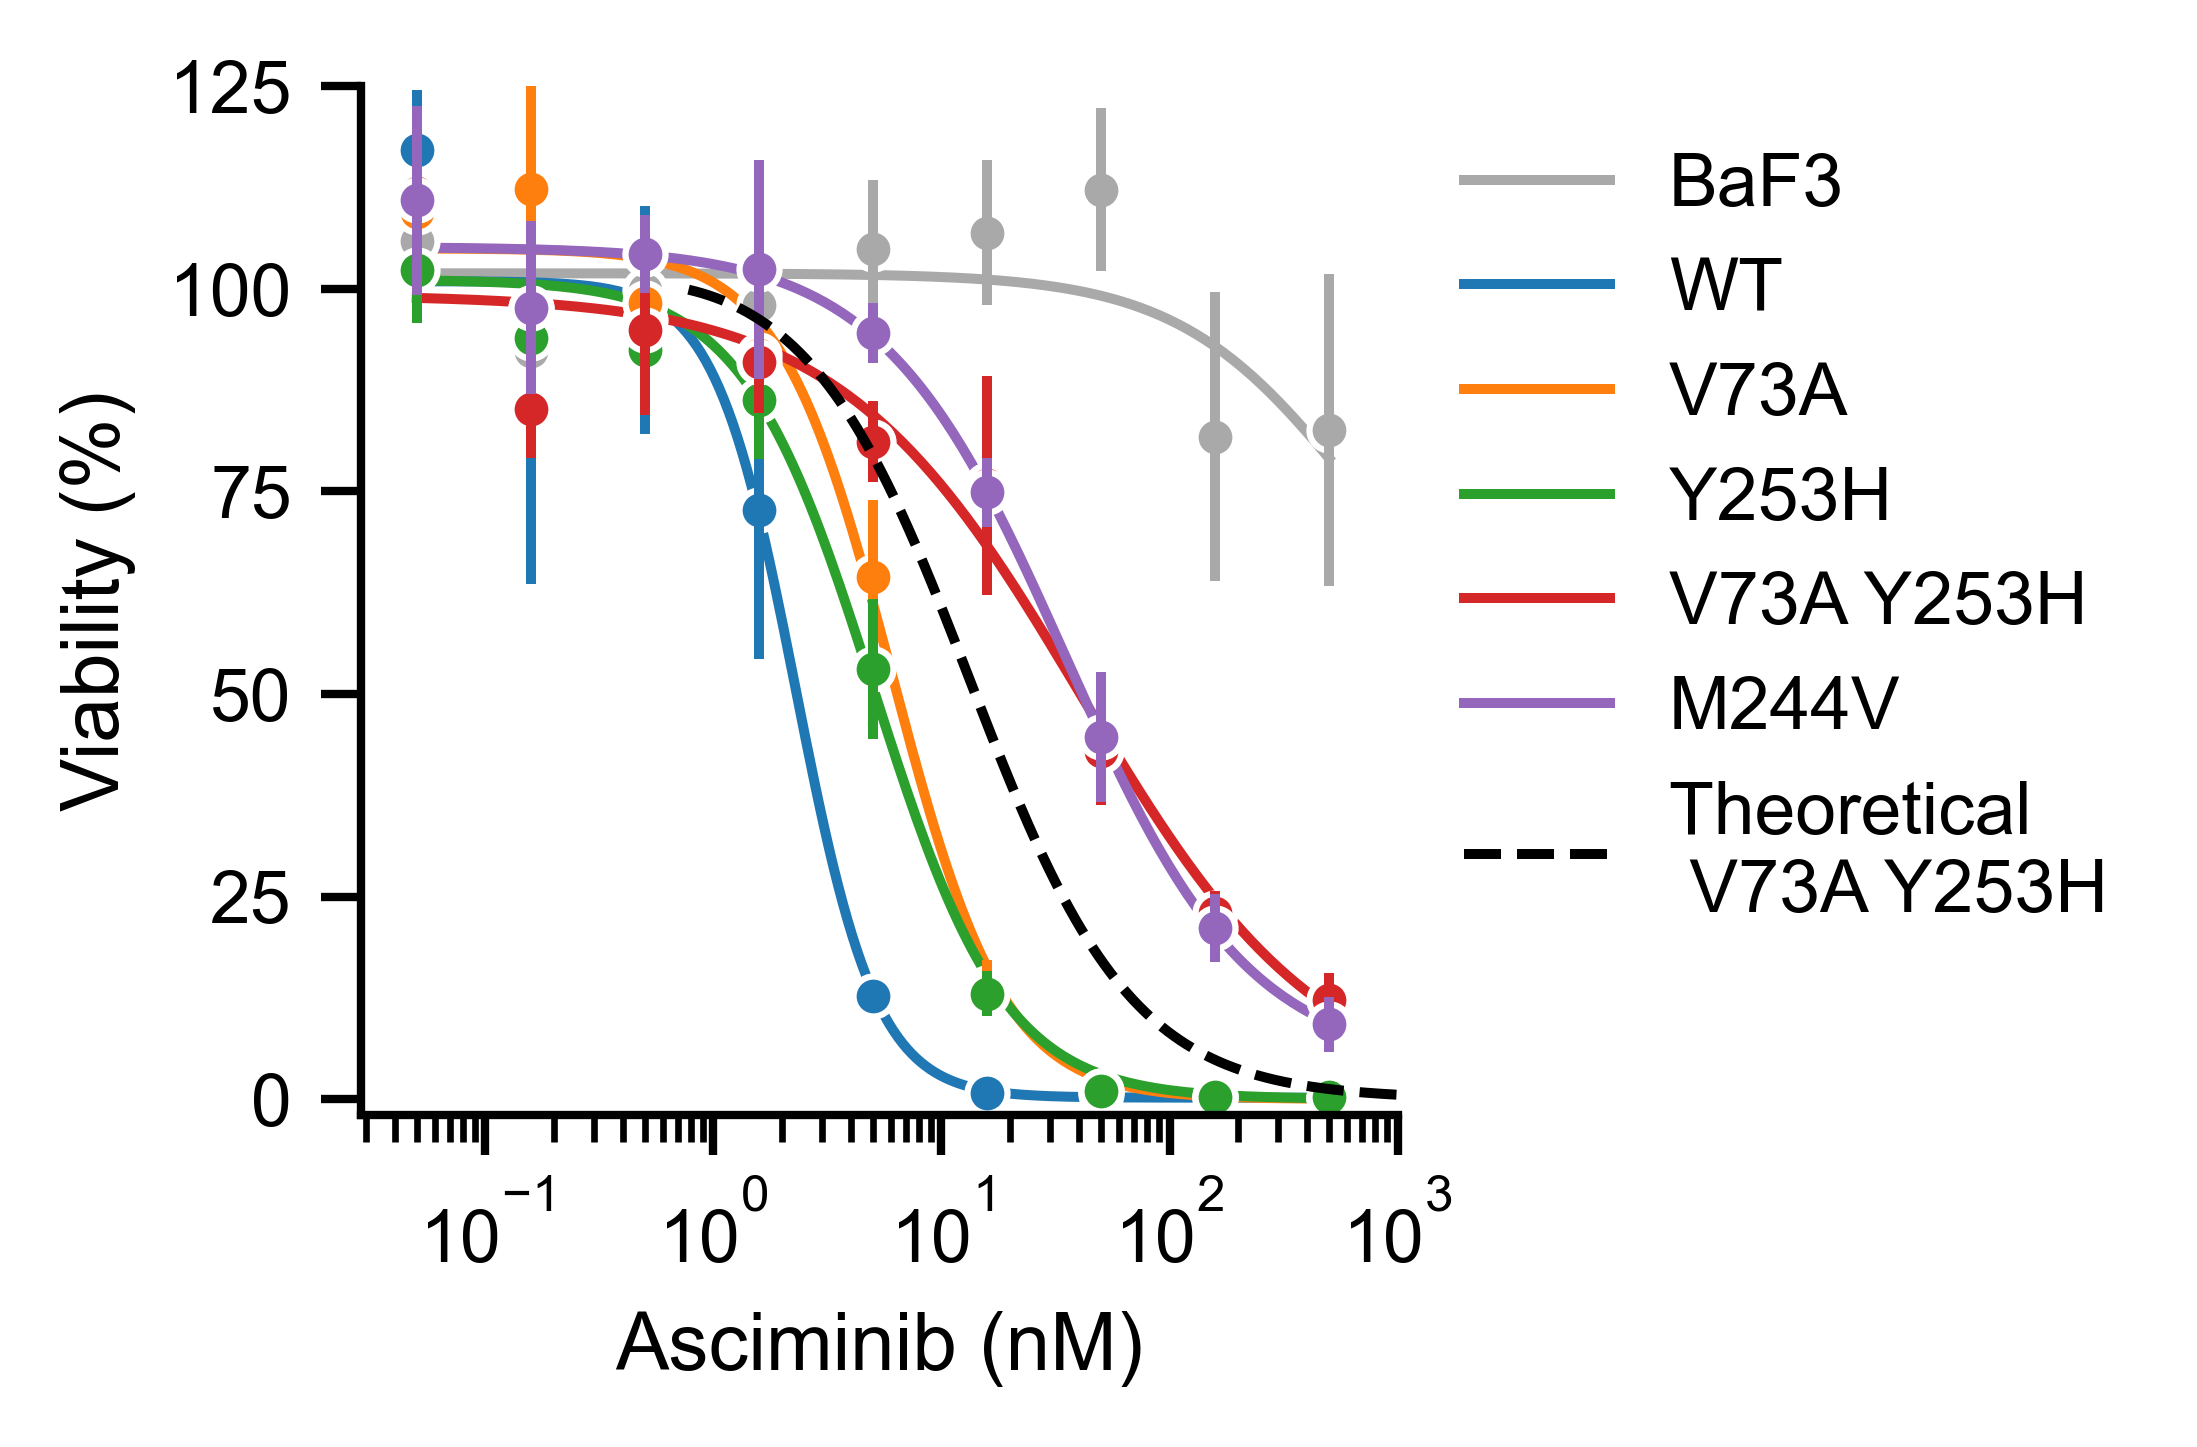

In [36]:
sns.set_context('paper')
mpl.rcParams['figure.figsize'] = 3.75,2.5
drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Cell', data=Asc_fit, hue_order = intrest, palette=['#A9A9A9'] + sns.color_palette())
#sns.scatterplot(x='Conc', y='Norm', hue='Cell', hue_order = intrest, data=Asc_data , palette=['#A9A9A9'] + sns.color_palette(), legend=False)
drug_resp = sns.lineplot(x='Conc', y='Norm', hue='Cell',  marker='o', linestyle='',
                         errorbar = 'sd', err_style='bars', hue_order = intrest, data=Asc_data , palette=['#A9A9A9'] + sns.color_palette(), legend=False)
drug_resp.set_yticks([0, 25, 50, 75, 100, 125])
drug_resp = sns.lineplot(x=C_AB_exp, y=v_grid*100, color='black', linestyle='--', label='Theoretical \n V73A Y253H')

drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel='Asciminib (nM)', xlim = [0,1000], ylim = [-2, 125])
drug_resp.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
drug_resp.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/Epistatic Confirmation/BaF3 WT and Y253H V73A DR260111.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

### Null Epistatic Calculation

In [43]:
pseudo_count = 1

WT_EC50 = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT'), 'EC50'].values
VA_EC50 = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='V73A'), 'EC50'].values
YH_EC50 = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H'), 'EC50'].values
VAYH_EC50 = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='V73A Y253H'), 'EC50'].values
VAYH_EC50_null = (VA_EC50 * YH_EC50) / WT_EC50

In [44]:
[WT_EC50, VA_EC50, YH_EC50]

[array([2.3]), array([6.05]), array([5.04])]

In [46]:
VAYH_EC50, VAYH_EC50_null

(array([41.36]), array([13.2573913]))

#### Error propogation

In [47]:
WT_EC50_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='WT'), 'EC50'].values
VA_EC50_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='V73A'), 'EC50'].values
YH_EC50_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='Y253H'), 'EC50'].values
VAYH_EC50_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='V73A Y253H'), 'EC50'].values

In [50]:
rel_error_sq = ((WT_EC50_sd / (WT_EC50))**2 +
                (VA_EC50_sd / (VA_EC50))**2 +
                (YH_EC50_sd / (YH_EC50))**2)

VAYH_EC50_null_sd = VAYH_EC50_null * np.sqrt(rel_error_sq)
VAYH_EC50_null_sd

array([3.33320833])

### Testing for a diffrence

Each dose-response condition consists of 27 observations (9 doses measured in triplicate). To account for the four-parameter sigmoidal model used to estimate the Bot parameter, the degrees of freedom are calculated as N−4, resulting in df=23.

In [51]:
# 1. Inputs (Replace with your actual variables)
ec50_obs = VAYH_EC50      # Observed double mutant Bot
se_obs = VAYH_EC50_sd    # SE of the observed EC50 fit
df_obs = 23                   # 27 points - 4 parameters

ec50_theo = VAYH_EC50_null      # Your calculated (A*B)/WT
se_theo = VAYH_EC50_null_sd    # Your propagated error
# For simplicity, df_theo is 23 since A, B, and WT all had same N
df_theo = 23 

# 2. Calculate Welches T-statistic

from scipy.stats import ttest_ind_from_stats
ttest_ind_from_stats(ec50_obs, se_obs, df_obs, ec50_theo, se_theo, df_theo, equal_var=False)

Ttest_indResult(statistic=array([4.58116803]), pvalue=array([0.0001378]))